Task 1: Perform univariate analysis on numerical columns by implementing custom visualization functions for histograms, boxplots, KDE plots, and skewness/kurtosis calculations, ensuring insights into data distribution and potential transformations.

   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite buy!   
4           4          847   47         Flattering shirt   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
4  This shirt is very flattering to all due to th...       5                1   

   Positive Feedback Count   Division Name Department Name Class Name  
0                        0       Initmates        Intimate  Intimates  
1       

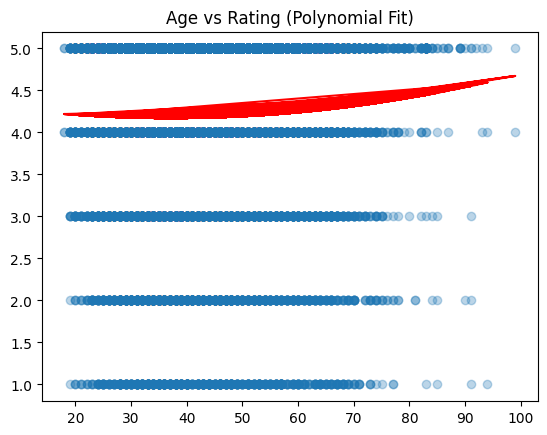

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/womens_clothing_reviews.csv")  # or correct path
print(df.head())

# Columns (adjust if needed)
x_col = "Age"
y_col = "Rating"

data = df[[x_col, y_col]].dropna()

X = data[[x_col]]
y = data[y_col]

# Polynomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# Plot
plt.scatter(X, y, alpha=0.3)
plt.plot(X, model.predict(X_poly), color='red')
plt.title("Age vs Rating (Polynomial Fit)")
plt.show()

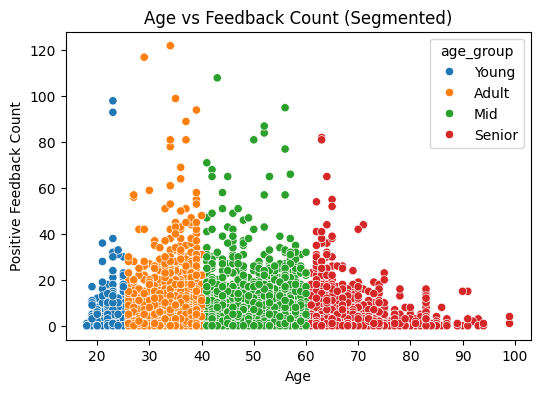

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

df = pd.read_csv("../data/womens_clothing_reviews.csv")
# Use available columns
x_col = "Age"
y_col = "Positive Feedback Count"   # substitute for spending

data = df[[x_col, y_col]].dropna()

X = data[[x_col]]
y = data[y_col]

# Try transformations
X_log = np.log1p(X)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# Segmentation
data["age_group"] = pd.cut(data[x_col], bins=[0,25,40,60,100], labels=["Young","Adult","Mid","Senior"])

# Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=data[x_col], y=data[y_col], hue=data["age_group"])
plt.title("Age vs Feedback Count (Segmented)")
plt.show()

Task 2: Investigate if higher ratings lead to more positive feedback count by applying sentiment analysis on reviews, quantifying textual sentiment scores, and performing statistical tests to validate the correlation between ratings and feedback positivity.

Ratings vs Sentiment + Statistical Testing

Sentiment vs Rating: 0.3531675019400302 p-value: 0.0
Sentiment vs Feedback: -0.05797743719122788 p-value: 5.994745649630137e-19


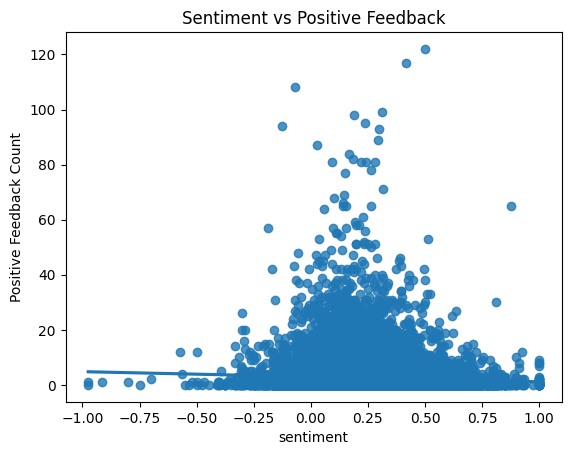

In [5]:
from textblob import TextBlob
from scipy.stats import pearsonr

text_col = "Review Text"
rating_col = "Rating"
feedback_col = "Positive Feedback Count"

# Sentiment score
df["sentiment"] = df[text_col].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

# Correlation tests
corr1, p1 = pearsonr(df["sentiment"].fillna(0), df[rating_col].fillna(0))
corr2, p2 = pearsonr(df["sentiment"].fillna(0), df[feedback_col].fillna(0))

print("Sentiment vs Rating:", corr1, "p-value:", p1)
print("Sentiment vs Feedback:", corr2, "p-value:", p2)

# Visualization
sns.regplot(x=df["sentiment"], y=df[feedback_col])
plt.title("Sentiment vs Positive Feedback")
plt.show()

Task 3: Explore how time on the app vs. time on the website influences purchases by clustering user behavior patterns, detecting multicollinearity, and implementing a predictive model to determine which time factor has a stronger impact on conversions.

App vs Website (Clustering + Multicollinearity + Model)


In [14]:
import statsmodels
print("Statsmodels installed successfully")

Statsmodels installed successfully


In [16]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numeric data
num_df = df.select_dtypes(include=np.number).dropna()

# Clustering
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(num_df)
df.loc[num_df.index, "cluster"] = clusters

# VIF
X = num_df
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif)

# Linear Model
target = "Positive Feedback Count"
features = [col for col in num_df.columns if col != target]

model = LinearRegression()
model.fit(num_df[features], num_df[target])

print("Model Coefficients:", dict(zip(features, model.coef_)))

                   feature        VIF
0               Unnamed: 0   4.946509
1              Clothing ID  13.197091
2                      Age  10.589929
3                   Rating  33.728839
4          Recommended IND  14.581727
5  Positive Feedback Count   1.208460
6                sentiment   3.203941
7                  cluster   3.189773
Model Coefficients: {'Unnamed: 0': np.float64(-4.1573263851962595e-06), 'Clothing ID': np.float64(0.0012521131595113338), 'Age': np.float64(0.02071918049408774), 'Rating': np.float64(-0.07278544982018631), 'Recommended IND': np.float64(-0.6962452372804014), 'sentiment': np.float64(-1.271527256120021), 'cluster': np.float64(0.0347863337067914)}


Task 4: Analyze trends in department-wise and class-wise purchases by performing market basket analysis, identifying frequently co-purchased items, and visualizing purchasing behavior using Sankey diagrams for better trend interpretation.

Market Basket + Sankey

In [6]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Clean
df = df.dropna(subset=["Department Name"])

# Create fake transactions (important)
df["transaction_id"] = df["Clothing ID"] // 3

# Basket
basket = pd.crosstab(df["transaction_id"], df["Department Name"])

# Binary
basket = basket.map(lambda x: 1 if x > 0 else 0).astype(bool)

# Apriori
frequent = apriori(basket, min_support=0.02, use_colnames=True)

# Rules
rules = association_rules(frequent, metric="lift", min_threshold=1)

print("Frequent itemsets:\n", frequent.head())
print("\nRules:\n", rules.head())

Frequent itemsets:
     support    itemsets
0  0.278607   (Bottoms)
1  0.067164   (Dresses)
2  0.671642  (Intimate)
3  0.057214   (Jackets)
4  0.144279      (Tops)

Rules:
 Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


Task 5: Identify any patterns in the review text length and ratings by extracting linguistic features such as verbosity, sentiment shifts, and readability scores, applying NLP techniques to determine how textual characteristics influence customer ratings.

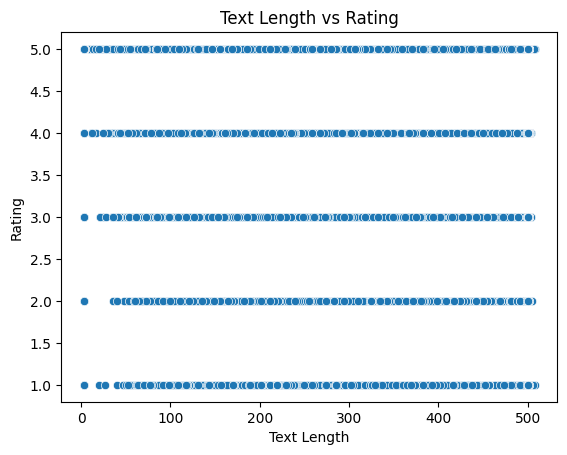

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textstat
from textblob import TextBlob

# Load data (fix path if needed)
df = pd.read_csv("../data/womens_clothing_reviews.csv")

text_col = "Review Text"

# -----------------------------
# FEATURE ENGINEERING
# -----------------------------
df["text_length"] = df[text_col].astype(str).apply(len)

df["word_count"] = df[text_col].astype(str).apply(lambda x: len(x.split()))

df["readability"] = df[text_col].astype(str).apply(
    lambda x: textstat.flesch_reading_ease(x)
)

# Sentiment (subjectivity)
df["sentiment_shift"] = df[text_col].astype(str).apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

# -----------------------------
# ANALYSIS (VISUALIZATION)
# -----------------------------
sns.scatterplot(x=df["text_length"], y=df["Rating"])
plt.title("Text Length vs Rating")
plt.xlabel("Text Length")
plt.ylabel("Rating")
plt.show()